In [111]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential,Model

from tensorflow.keras.layers import (Embedding,SimpleRNN,LSTM,Bidirectional,Dense,Dropout)

In [1]:
import pandas as pd

df=pd.read_csv("../data/processed/final_featuresWord2vec.csv")

In [2]:
df=df[['question1','question2','is_duplicate']]

In [3]:
df.head()

,question1,question2,is_duplicate
0,how do i play pokémon go in korea,how do i play pokémon go in china,0
1,what are some of the best side dish for crab cake,what are some good side dish for buffalo chicken,0
2,which is more advi and better materi for a cra...,what is the best server setup for buddypress,0
3,how do i improv logic program skill,how can i improv my logic skill for program,1
4,how close we are to see 3rd world war,how close is a world war iii,1


Question Pair
      ↓
Tokenizer
      ↓
Word Sequences
      ↓
Embedding Layer
      ↓
LSTM/BiLSTM
      ↓
Prediction

In [5]:
df.isnull().sum()

question1       2
question2       1
is_duplicate    0
dtype: int64

In [6]:
df.dropna(inplace=True)


In [7]:
df.isnull().sum()

question1       0
question2       0
is_duplicate    0
dtype: int64

# Tokenization

In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer=Tokenizer(
    num_words=50000,
    oov_token='<OOV>'
)

all_questions=(
    df['question1'].astype(str).tolist()+df['question2'].astype(str).tolist()
)

tokenizer.fit_on_texts(all_questions)

In [10]:
#conver text->sequence

q1_seq=tokenizer.texts_to_sequences(
    df['question1'].astype(str)
)

q2_seq=tokenizer.texts_to_sequences(
    df['question2'].astype(str)
)

### Padding


In [78]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN=50

q1_pad=pad_sequences(q1_seq,maxlen=MAX_LEN,padding='post')

q2_pad=pad_sequences(q2_seq,maxlen=MAX_LEN,padding='post')

In [67]:
#here we have to send both questions and encoder will work on it so we will need 2 sets of train set

In [79]:
X1_train,X1_test,X2_train,X2_test,y_train,y_test=train_test_split(q1_pad,q2_pad,df['is_duplicate'],test_size=0.2,random_state=42,stratify=df['is_duplicate'])

### Prepare single input for RNN

In [80]:
X_train = np.concatenate(
    [X1_train, X2_train],
    axis=1
)

X_test = np.concatenate(
    [X1_test, X2_test],
    axis=1
)

In [81]:
print(X_train.shape)
print(X_test.shape)

(39997, 100)
(10000, 100)


# Simple RNN model

In [ ]:
#rnn is san with MAX_LEN=30 while tokenization and rest are with MAX_LEN=50

In [71]:
rnn_model=Sequential()

rnn_model.add(
    Embedding(
        input_dim=50000,
        output_dim=128,
        
    )
)

rnn_model.add(
    SimpleRNN(
        64,
        
    )
)


rnn_model.add(Dense(1,activation='sigmoid'))

In [72]:
#compile

rnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [73]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [74]:
history_rnn=rnn_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=64,callbacks=[early_stop])

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 81ms/step - accuracy: 0.6456 - loss: 0.6393 - val_accuracy: 0.6609 - val_loss: 0.6229
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.7259 - loss: 0.5521 - val_accuracy: 0.7197 - val_loss: 0.5744
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 77ms/step - accuracy: 0.8001 - loss: 0.4335 - val_accuracy: 0.7193 - val_loss: 0.6054
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - accuracy: 0.8654 - loss: 0.3152 - val_accuracy: 0.7014 - val_loss: 0.6583


In [75]:
rnn_loss,rnn_acc=rnn_model.evaluate(
    X_test,
    y_test
)

print(rnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7202 - loss: 0.5672
0.7202000021934509


### storing result

In [76]:
results_df = pd.read_csv('model_results.csv')

results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380


In [77]:
new_row=pd.DataFrame([{
    "model":"SimpleRnn",
    "features":"Deep Learning Approach",
    "accuracy":rnn_acc
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [49]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7072


# LSTM

In [94]:
lstm_model=Sequential()

lstm_model.add(Embedding(input_dim=50000,output_dim=128))

lstm_model.add(LSTM(128))
lstm_model.add(Dense(64,activation='relu'))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1, activation='sigmoid'))

In [95]:
lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [96]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [97]:
history_lstm=lstm_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=128,callbacks=[early_stop])

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 352ms/step - accuracy: 0.6305 - loss: 0.6609 - val_accuracy: 0.6326 - val_loss: 0.6605
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 87s 348ms/step - accuracy: 0.6305 - loss: 0.6598 - val_accuracy: 0.6326 - val_loss: 0.6571
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 92s 368ms/step - accuracy: 0.6333 - loss: 0.6312 - val_accuracy: 0.6819 - val_loss: 0.5962
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 255ms/step - accuracy: 0.7030 - loss: 0.5660 - val_accuracy: 0.7171 - val_loss: 0.5711
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 53s 213ms/step - accuracy: 0.7546 - loss: 0.5033 - val_accuracy: 0.7004 - val_loss: 0.5706
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.7902 - loss: 0.4477 - val_accuracy: 0.7130 - val_loss: 0.5643
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.8287 - loss: 0.3806 - val_accuracy: 0.7303 - val_loss: 0.5909
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 206ms/step - accuracy: 0.8615 - loss: 0

In [99]:
lstm_loss,lstm_acc=lstm_model.evaluate(
    X_test,y_test
)

print(lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7118 - loss: 0.5547
0.7117999792098999


In [100]:
new_row=pd.DataFrame([{
    "model":"LSTM",
    "features":"Deep Learning Approach",
    "accuracy":lstm_acc
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [102]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118


# BiLSTM

In [104]:
bilstm_model=Sequential()

bilstm_model.add(Embedding(input_dim=50000,output_dim=128))
bilstm_model.add(Bidirectional(LSTM(64)))
bilstm_model.add(Dense(1,activation='sigmoid'))

In [105]:
# compile

bilstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [106]:
history_bilstm=bilstm_model.fit(X_train,y_train,validation_split=0.2,epochs=10,batch_size=128,callbacks=[early_stop])

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 44s 162ms/step - accuracy: 0.6925 - loss: 0.5853 - val_accuracy: 0.7266 - val_loss: 0.5520
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 164ms/step - accuracy: 0.7663 - loss: 0.4901 - val_accuracy: 0.7271 - val_loss: 0.5574
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 41s 165ms/step - accuracy: 0.8034 - loss: 0.4247 - val_accuracy: 0.7304 - val_loss: 0.5815


In [107]:
bilstm_loss,bilstm_acc=bilstm_model.evaluate(X_test,y_test)

print(bilstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7334 - loss: 0.5418
0.7333999872207642


In [108]:
new_row=pd.DataFrame([{
    "model":"BiLSTM",
    "features":"Deep Learning Approach",
    "accuracy":bilstm_acc
}])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [109]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118
8,BiLSTM,Deep Learning Approach,0.7334


# Siamese Network

### BUILD ENCODER

In [132]:
from tensorflow.keras.layers import Input

VOCAB_SIZE=50000
MAX_LEN=50
input_layer=Input(shape=(MAX_LEN,))

In [133]:
# EMBEDDING

x=Embedding(input_dim=VOCAB_SIZE,output_dim=128)(input_layer)

In [134]:
#Lstm

x=LSTM(64)(x)

In [135]:
#craete encoder

encoder=Model(input_layer,x)

In [136]:
#creating two inputs

input_q1=Input(shape=(MAX_LEN,))
input_q2=Input(shape=(MAX_LEN,))

In [137]:
#pass input through Encoder

encoded_q1=encoder(input_q1)
encoded_q2=encoder(input_q2)

In [138]:
# merge representations

In [139]:
from tensorflow.keras.layers import Concatenate

In [140]:
merged=Concatenate()([encoded_q1,encoded_q2])

In [141]:
x=Dense(128,activation='relu')(merged)

x=Dropout(0.3)(x)

x=Dense(64,activation='relu')(x)

output=Dense(1,activation='sigmoid')(x)

In [142]:
#build final model

siamese_model=Model(
    inputs=[input_q1,input_q2],
    outputs=output
)

In [143]:
siamese_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [145]:
history=siamese_model.fit([X1_train,X2_train],y_train,validation_split=0.2,epochs=10,batch_size=128,callbacks=[early_stop])

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.7288 - loss: 0.5428 - val_accuracy: 0.7274 - val_loss: 0.5509
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.7749 - loss: 0.4769 - val_accuracy: 0.7186 - val_loss: 0.5585
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.8110 - loss: 0.4178 - val_accuracy: 0.7355 - val_loss: 0.5605


In [147]:
siamese_loss,siamese_acc=siamese_model.evaluate(
    [X1_test,X2_test],
    y_test
)

print(siamese_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7279 - loss: 0.5466
0.7279000282287598


In [150]:
new_row=pd.DataFrame([
    {
        "model":"Siamese",
        "features":"Dl approach",
        "accuracy":siamese_acc
    }
])

results_df=pd.concat(
    [results_df,new_row],
    ignore_index=True
)

In [151]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118
8,BiLSTM,Deep Learning Approach,0.7334
9,Siamese,Dl approach,0.7279


In [152]:
preds = siamese_model.predict(
    [X1_test, X2_test]
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [153]:
preds = (preds > 0.5).astype(int)

In [154]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.74      0.87      0.80      6309
           1       0.68      0.49      0.57      3691

    accuracy                           0.73     10000
   macro avg       0.71      0.68      0.69     10000
weighted avg       0.72      0.73      0.72     10000



In [157]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [158]:
print(history.history['accuracy'])

[0.7287558317184448, 0.7748851180076599, 0.8109822869300842]


In [159]:
print(history.history['val_accuracy'])

[0.7273749709129333, 0.718625009059906, 0.7354999780654907]


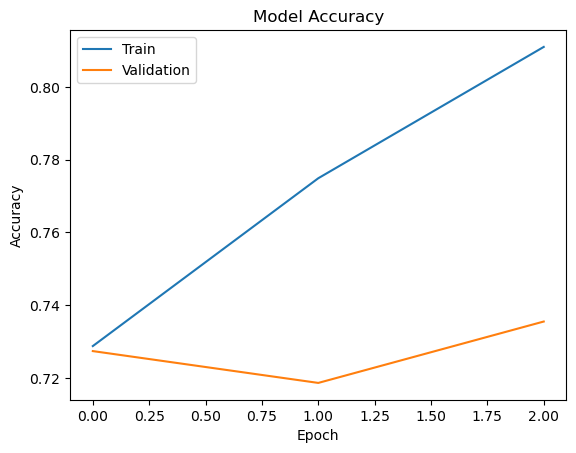

In [160]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

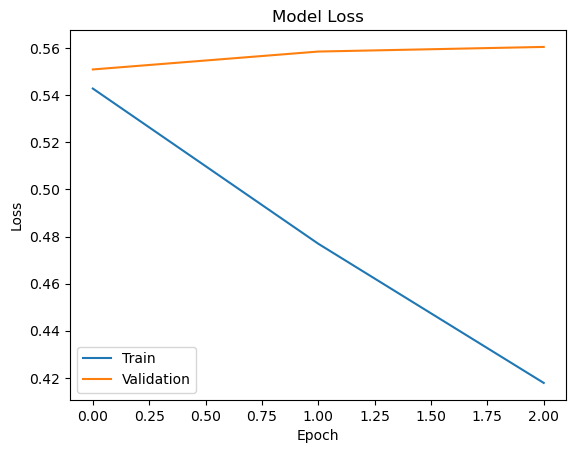

In [161]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [155]:
results_df.to_csv("model_results.csv", index=False)

In [156]:
results_df

,model,features,accuracy
0,Logistic regression,TFIDF ONLY,0.6676
1,Random Forest,TF-IDF only,0.7190
2,XGBoost,TF-IDF only,0.7302
3,Logistic regression,TFIDF ONLY+Word2vec,0.6713
4,Random Forest,TF-IDF only+word2vec,0.7312
5,XGBoost,TF-IDF only+word2vec,0.7380
6,SimpleRnn,Deep Learning Approach,0.7202
7,LSTM,Deep Learning Approach,0.7118
8,BiLSTM,Deep Learning Approach,0.7334
9,Siamese,Dl approach,0.7279


### Conclusion 

Classical feature engineering combined with XGBoost achieved the best performance (73.8% accuracy) on the 50k sample dataset, outperforming the tested deep learning architectures. This suggests that carefully engineered lexical and semantic features remain highly effective for duplicate question detection on medium-sized datasets.